# Example script 

This notebook is an example of how to caluclate π-π stacking with the pipi_stack module which uses the gemoetric criteria presented in the article https://doi.org/10.1039/D5FD00052A. In this example we will look at a trajectory of 100 lignin tetramers (i.e. 100*4=400 rings) of G-monomers connected with β-O4 linkages in water.

Let's start by loading in the required packages.

In [1]:
import numpy as np
print("Numpy version: ", np.__version__)
import matplotlib.pyplot as plt
import MDAnalysis as mda
print("MDAnalysis version: ", mda.__version__)
import nglview as nv #for plotting the trajectories
from pipi_stack import pipi_stacking as pipi

Numpy version:  2.3.3
MDAnalysis version:  2.9.0


Load in the data using MDAnalysis.

In [2]:
# Load MDAnalysis universe from topology + trajectory of example data containing 100 lignin tetramers in water
u = mda.Universe("example_data/prod.tpr", "example_data/prod.xtc")
dt = u.trajectory.dt
N_frames = len(u.trajectory)
N_atoms = len(u.atoms)

print(f"Universe with {N_atoms} atoms, {N_frames} frames and {dt} ps between frames.")

Universe with 97255 atoms, 101 frames and 100.0 ps between frames.


Select only the atoms making up the aromatic rings then unwrap the trajectory such that the bonds do not break (required for the analysis). The reason this is not done automatically is to keep it general for any system.

This is the only tricky part as we need to extract the ring indices of our specific system. In this example the tetramer molecules are made up of 103 atoms each. We start by extracting the indices for the ring atoms in the first tetramer (this had to be done manually by visual inspection) and then taking the rest of the ring atoms by list comprehension. The lignin atoms come before the water atoms in this example.

Note: we could also prepare our trajectories beforehand, but using MDAnalysis this is readily done in Python.

In [3]:
# Indices of the ring atoms on the tetramer 
idx_ring_atoms = [[0, 1, 2, 5, 7, 8],
                [16, 17, 18, 21, 23, 24],
                [31, 32, 33, 36, 38, 39],
                [47, 48, 49, 50, 52, 53]]
N_molecules = 100 #number of tetramers
N_atoms_per_molecule = 103

# Take indices of all tetramers
idx_select = [[idx + 103*i_molecule for idx in ring] for i_molecule in range(N_molecules) for ring in idx_ring_atoms]
idx_select_flat = [idx for ring in idx_select for idx in ring]

# Select the atom group consisting of only the ring atoms
str_extract = "index " + " ".join(str(idx) for idx in idx_select_flat)
ring_atoms = u.select_atoms(str_extract)


In [4]:
# Unwrap the trajectory to keep the rings whole
from MDAnalysis import transformations
unwrap = [transformations.unwrap(ring_atoms)]
u.trajectory.add_transformations(*unwrap)

Make a plot to confirm that the bonds do not break through the boundaries.

In [5]:
import nglview as nv

view = nv.show_mdanalysis(u)
view.clear_representations()
view.add_representation('ball+stick', selection=idx_select_flat)
view.add_unitcell()
view.center(selection=idx_select_flat)
view.layout.width = "800px"
view.layout.height = "600px"
view



NGLWidget(layout=Layout(height='600px', width='800px'), max_frame=100)

We start by extracting all the aromatic ring pairs within a cut-off distance of 10 Å, using the pair_cutoff() function. This gives lists of the distance, angle, lateral displacement and the atomic ring objects of the ring pairs. This can take a long time, but gives us the advantage to experiment with conditions without having to loop through all the rings again. 

In [6]:
cutoff = 10
dist_list, ang_list, latdisp_list, AR_pair_list = pipi.pair_cutoff(u, idx_select, cutoff=cutoff)

Another advantage is that we can look of the distributions of one criterion for a range of the other two criteria. This can be achieved by using the criteria_2D() command and can help us decide which ranges to use for the stacking conditions. 

Note: the angle calculation between ring normals can sometimes be higher due to the normals pointing at different directions, but this is not something we want to distinguish for the stacking, thus the angle has to be taken at two ranges. 

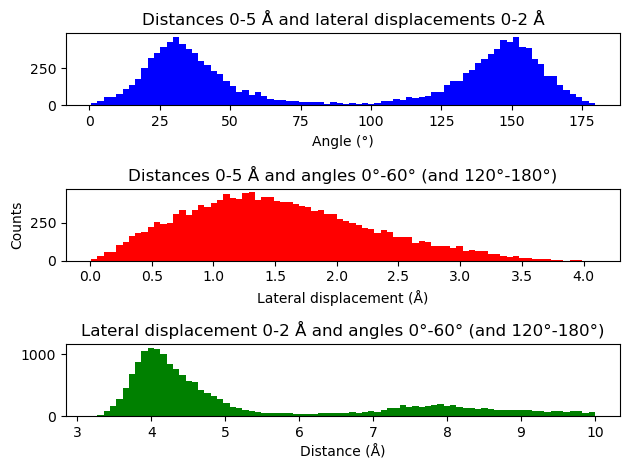

In [7]:
# Calculate the distributions 
ang_test = pipi.criteria_2D(dist_list, (0,5), latdisp_list, (0,2), ang_list)
latdisp_test = np.concatenate([pipi.criteria_2D(dist_list, (0,5), ang_list, (0,60), latdisp_list), pipi.criteria_2D(dist_list, (0,5), ang_list, (120,180), latdisp_list)])
dist_test = np.concatenate([pipi.criteria_2D(latdisp_list, (0,2), ang_list, (0,60), dist_list), pipi.criteria_2D(latdisp_list, (0,2), ang_list, (120,180), dist_list)])

# Plot histograms
fig, [ax1, ax2, ax3] = plt.subplots(nrows=3, ncols=1)

ax1.set_title("Distances 0-5 Å and lateral displacements 0-2 Å")
h1 = ax1.hist(ang_test, bins = 80, color='blue')
ax1.set_xlabel("Angle (°)")

ax2.set_title("Distances 0-5 Å and angles 0°-60° (and 120°-180°)")
h2 = ax2.hist(latdisp_test, bins=80, color='red')
ax2.set_ylabel("Counts")
ax2.set_xlabel("Lateral displacement (Å)")

ax3.set_title("Lateral displacement 0-2 Å and angles 0°-60° (and 120°-180°)")
h3 = ax3.hist(dist_test, bins=80, color='green')
ax3.set_xlabel("Distance (Å)")

plt.tight_layout()

We see that when the rings are rather close there is a clear favorable orientation around 30°. We see a lateral displacement "peak" around 1.4 Å and distance 4.1 Å for the given ranges shown above.

Maybe more clearer is to get 2D distributions of two of the criteria based on the range of one of the criteria. We can use criteria_1D() for this.

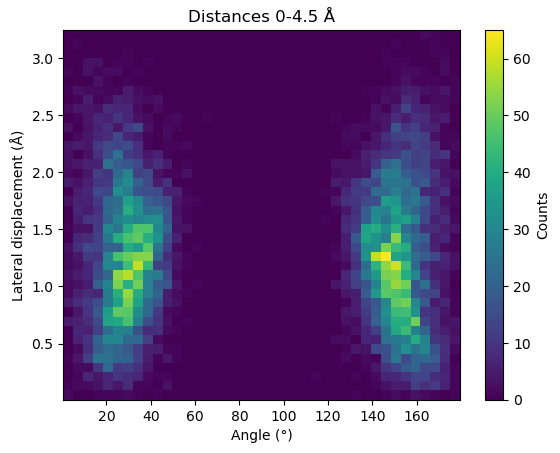

In [8]:
# Calculate the distribution
latdisp_test2, ang_test2 = pipi.criteria_1D(dist_list, (0,4.5), latdisp_list, ang_list)

# Plot the 2D histogram
plt.title("Distances 0-4.5 Å")
hist = plt.hist2d(ang_test2, latdisp_test2, bins=40)
plt.xlabel("Angle (°)")
plt.ylabel("Lateral displacement (Å)")

cb = plt.colorbar()
cb.set_label("Counts")

After inspection we can set our criteria and caluclate the stackings using the function calculate_stackings() which should run very fast.

Note: we do not need two angle ranges here unless circular is set to False in the calculate_stackings() function. 

In [ ]:
import importlib
importlib.reload(pipi)

# The geometric criteria [min, max]
dist_range = [0, 4.5]
ang_range = [0, 50]
latdisp_range = [0, 2]

dist_stack, ang_stack, latdisp_stack, AR_pair_stack = pipi.calculate_stackings([dist_list, ang_list, latdisp_list, AR_pair_list], d_range=dist_range, ang_range=ang_range, latdisp_range=latdisp_range)

---Average values of the stackings---
Number per frame: 91 +/- 6
Distance: 4.02 +/- 0.25
Angle: 92.1 +/- 62.1
Lateral displacement: 1.13 +/- 0.46


The output from the calculations give lists similar to the pair_cutoff() function but here for the stacked rings. The aromatic ring objects can give us the information about the aromatic rings of the stacking (such as their position, normal vector and the atomic indices) and you can even plot it.

In [ ]:
frame = 0
i_stacking = 0

ar1, ar2 = AR_pair_stack[frame][i_stacking]
print(ar1)
print(ar2)

idx_stack = np.concatenate((ar1.indices, ar2.indices))

# Plot the stacking 
view = nv.show_mdanalysis(u)
view.clear_representations()
view.add_representation('ball+stick', selection=idx_stack)
view.center(selection=idx_stack)
view.add_unitcell()
view.frame = frame
view.layout.width = "800px"
view.layout.height = "600px"
view



Aromatic ring located at (x,y,z) = (42.23,-0.9,8.78) with normal vector (nx,ny,nx) = (-0.69,0.48,0.54). 
Aromatic ring located at (x,y,z) = (39.37,1.15,10.16) with normal vector (nx,ny,nx) = (0.64,-0.74,-0.2). 


NGLWidget(layout=Layout(height='600px', width='800px'), max_frame=100)